# Bank Customer Churn Prediction — Machine Learning Module

**Part of a larger Big Data Bank System**

This notebook develops the **Machine Learning module** for a bank customer
churn analysis and prediction system. It is not a standalone Kaggle
exercise: the model, preprocessing pipeline, and Streamlit demo produced
here are designed to plug into a larger banking system that handles
customer data using Big Data technologies.

**Scope of this notebook**

- Inspect and understand the real, provided dataset (no assumptions about schema)
- Clean the data
- Perform light, business-focused exploratory data analysis (EDA)
- Engineer a small set of business-motivated features
- Build a leakage-free preprocessing pipeline
- Internally compare several classification algorithms
- Select **one** final model based on cross-validated generalization, not training accuracy
- Tune, evaluate, and analyze that model for overfitting
- Save the final pipeline for use by a lightweight Streamlit demo


## 2. Business Problem

**Question:** *Which customers are at risk of leaving the bank?*

Customer churn — a customer closing their account or moving their business
to a competitor — directly affects bank revenue and the cost of acquiring
replacement customers. If the bank can identify customers who are likely to
churn **before** they leave, the retention team can intervene (e.g. with
targeted offers, outreach, or service improvements).

This ML module's job is strictly to **estimate churn risk** for a customer,
expressed as:

- a churn probability,
- a churn / stay classification,
- a demonstration risk level (Low / Medium / High).

It does **not** make financial decisions (loan approvals, transaction
approvals, etc.) — those remain the responsibility of other modules /
human decision-makers in the larger Bank System.


## 3. Dataset Overview

We start by loading the actual provided dataset and inspecting it with no
assumptions about its schema.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

df_raw = pd.read_csv('../data/raw/Bank_Customer_Churn_Prediction.csv')
print("Shape (rows, columns):", df_raw.shape)
df_raw.head()


Shape (rows, columns): (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print("Column names and dtypes:")
df_raw.dtypes


Column names and dtypes:


customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

## 4. Data Understanding

Before touching the data, we check: missing values, duplicate rows,
duplicate identifiers, unique values per categorical column, and the
target distribution.


In [3]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Fully duplicated rows:", df_raw.duplicated().sum())
print("Duplicated customer_id values:", df_raw['customer_id'].duplicated().sum())


Missing values per column:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Fully duplicated rows: 0
Duplicated customer_id values: 0


In [4]:
categorical_like_cols = ['country', 'gender', 'products_number', 'credit_card', 'active_member', 'tenure']
for c in categorical_like_cols:
    print(f"{c}: {sorted(df_raw[c].unique().tolist())}")


country: ['France', 'Germany', 'Spain']
gender: ['Female', 'Male']
products_number: [1, 2, 3, 4]
credit_card: [0, 1]
active_member: [0, 1]
tenure: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [5]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


In [6]:
print("Target column: 'churn'")
print(df_raw['churn'].value_counts())
print()
print(df_raw['churn'].value_counts(normalize=True).rename('proportion'))


Target column: 'churn'
churn
0    7963
1    2037
Name: count, dtype: int64

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


**Observations from Data Understanding**

- The dataset has **10,000 rows and 12 columns**, with **no missing values**
  and **no duplicate rows** (either at the full-row level or the
  `customer_id` level).
- `customer_id` is a unique **identifier** with no predictive meaning — it
  will be removed before modelling to avoid the model memorizing IDs
  (a form of leakage / noise).
- The target column is **`churn`** (1 = customer churned, 0 = customer
  stayed). It is **imbalanced**: about **20.4% churn** vs **79.6% stay**.
  This motivates using **stratified** splitting and cross-validation, and
  looking beyond raw accuracy (precision/recall/F1) at evaluation time.
- Categorical columns: `country` (France / Spain / Germany), `gender`
  (Female / Male).
- Numerical columns: `credit_score`, `age`, `tenure`, `balance`,
  `products_number`, `estimated_salary`.
- Binary flag columns: `credit_card`, `active_member`.
- No obvious leakage columns are present — none of the remaining columns
  are direct proxies computed *from* the target.

**Role of each important feature (banking perspective)**

| Column | Business meaning |
|---|---|
| `credit_score` | Creditworthiness indicator; may relate to financial stress |
| `country` | Region of the customer's branch/market |
| `gender` | Customer demographic |
| `age` | Customer's life stage |
| `tenure` | Years the customer has been with the bank |
| `balance` | Current account balance — engagement / product depth |
| `products_number` | Number of bank products held — cross-sell depth |
| `credit_card` | Whether the customer holds a credit card (stickier product) |
| `active_member` | Whether the bank considers the customer actively engaged |
| `estimated_salary` | Estimated income level |
| `churn` | **Target** — did the customer leave the bank? |


## 5. Data Cleaning

Cleaning decisions, based on what section 4 actually found in the data:

1. **Drop `customer_id`** — a unique identifier with no predictive
   meaning for a *new, unseen* customer.
2. **Drop full-row duplicates** if any exist (defensive step — none were
   found, but this keeps the pipeline correct if the source data changes).
3. **No missing values** were found, so no imputation is required at the
   cleaning stage (the sklearn pipeline still includes imputers for
   robustness/production-safety, in case future incoming data has gaps).
4. **No invalid values** were found (e.g. no negative ages, no negative
   balances, no out-of-range binary flags).
5. We **do not blindly remove outliers** (e.g. very high balances or very
   high credit scores) — these are plausible, legitimate banking values
   and may be informative for churn.


In [7]:
print("Before Cleaning:")
print(f"Rows x Columns = {df_raw.shape[0]} x {df_raw.shape[1]}")

df_clean = df_raw.drop_duplicates().copy()
df_clean = df_clean.drop(columns=['customer_id'])

print()
print("After Cleaning:")
print(f"Rows x Columns = {df_clean.shape[0]} x {df_clean.shape[1]}")


Before Cleaning:
Rows x Columns = 10000 x 12

After Cleaning:
Rows x Columns = 10000 x 11


## 6. Exploratory Data Analysis (EDA)

A focused set of ~7 visualizations aimed at business insight, not
exhaustive exploration.


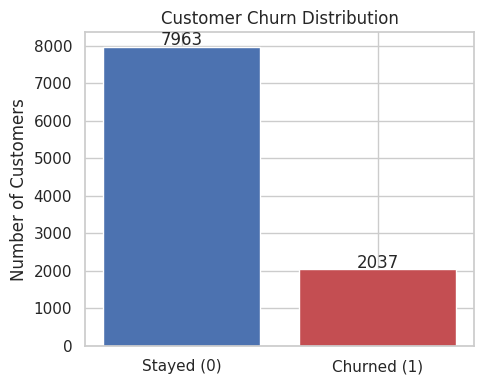

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts = df_clean['churn'].value_counts().sort_index()
ax.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=['#4C72B0', '#C44E52'])
ax.set_title('Customer Churn Distribution')
ax.set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()


**Interpretation:** The dataset is imbalanced — roughly 1 in 5 customers
in this dataset churned. This confirms the need for stratified
train/test splitting and cross-validation, and for evaluating the final
model with precision/recall/F1 in addition to accuracy.

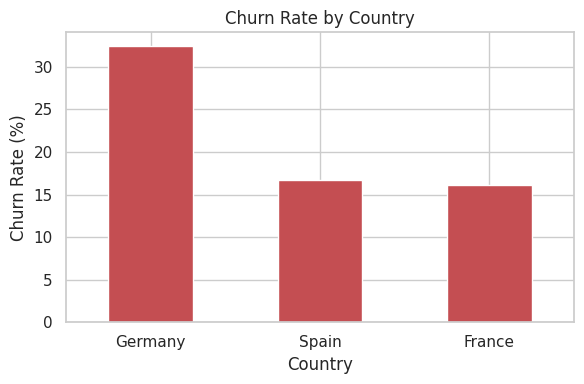

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_country = pd.crosstab(df_clean['country'], df_clean['churn'], normalize='index') * 100
churn_by_country[1].sort_values(ascending=False).plot(kind='bar', color='#C44E52', ax=ax)
ax.set_title('Churn Rate by Country')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Country')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** Germany shows a noticeably higher churn rate than
France or Spain. This is a useful signal for the retention team — regional
factors (competition, service quality, local offers) may be worth
investigating outside the scope of this ML module.

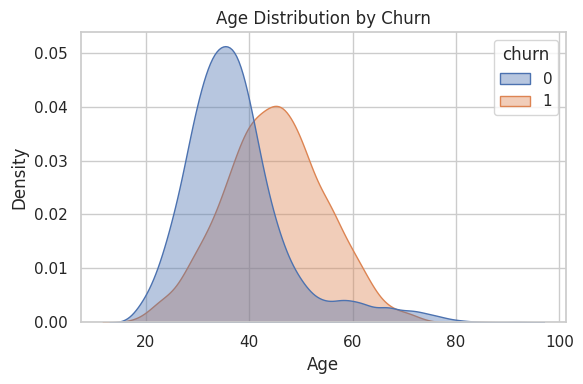

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=df_clean, x='age', hue='churn', fill=True, common_norm=False, alpha=0.4, ax=ax)
ax.set_title('Age Distribution by Churn')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()


**Interpretation:** Churned customers skew somewhat older on average
than retained customers, with churn concentrated in the roughly 40–60
age range. Very young customers churn less in this dataset.

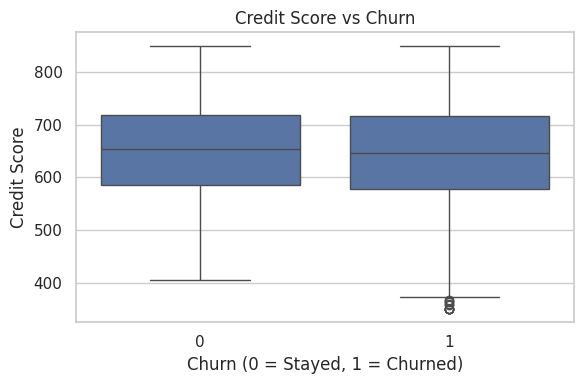

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_clean, x='churn', y='credit_score', ax=ax)
ax.set_title('Credit Score vs Churn')
ax.set_xlabel('Churn (0 = Stayed, 1 = Churned)')
ax.set_ylabel('Credit Score')
plt.tight_layout()
plt.show()


**Interpretation:** Credit score distributions look broadly similar
between churned and retained customers, with only a slightly lower median
for churned customers. On its own, credit score does not appear to be a
strong separator of churn.

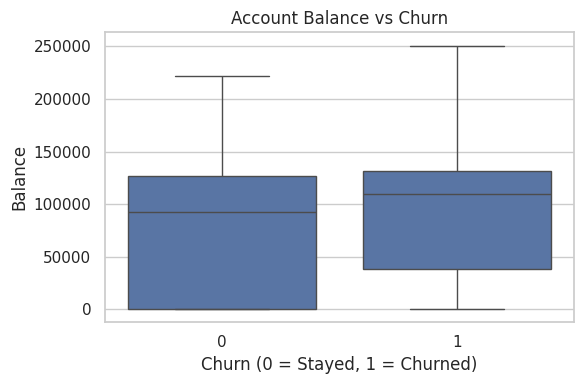

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_clean, x='churn', y='balance', ax=ax)
ax.set_title('Account Balance vs Churn')
ax.set_xlabel('Churn (0 = Stayed, 1 = Churned)')
ax.set_ylabel('Balance')
plt.tight_layout()
plt.show()


**Interpretation:** Churned customers tend to have *higher* median
balances than retained customers. This is somewhat counter-intuitive from
a simple "loyalty" perspective, but is a well-known pattern in this kind
of banking data: customers with larger balances may have more attractive
alternatives elsewhere and more incentive to shop around.

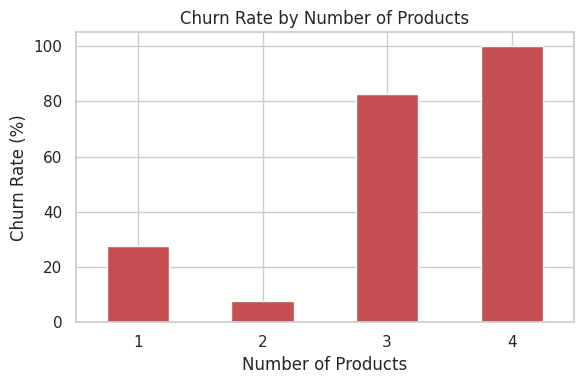

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_products = pd.crosstab(df_clean['products_number'], df_clean['churn'], normalize='index') * 100
churn_by_products[1].plot(kind='bar', color='#C44E52', ax=ax)
ax.set_title('Churn Rate by Number of Products')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Number of Products')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** Customers with exactly one product churn at a
moderate rate, customers with two products churn the least, and customers
with **three or four** products churn at a dramatically higher rate. This
suggests that beyond a certain point, holding many products may reflect
customers who are dissatisfied or being over-sold rather than more loyal
— a strong candidate signal for the model and for the business.

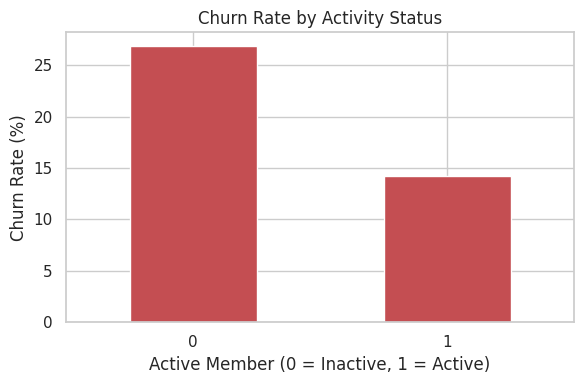

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_active = pd.crosstab(df_clean['active_member'], df_clean['churn'], normalize='index') * 100
churn_by_active[1].plot(kind='bar', color='#C44E52', ax=ax)
ax.set_title('Churn Rate by Activity Status')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Active Member (0 = Inactive, 1 = Active)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** Inactive members churn at roughly double the rate
of active members. This supports the intuitive idea that disengagement
(inactivity) is associated with a higher likelihood of leaving the bank.

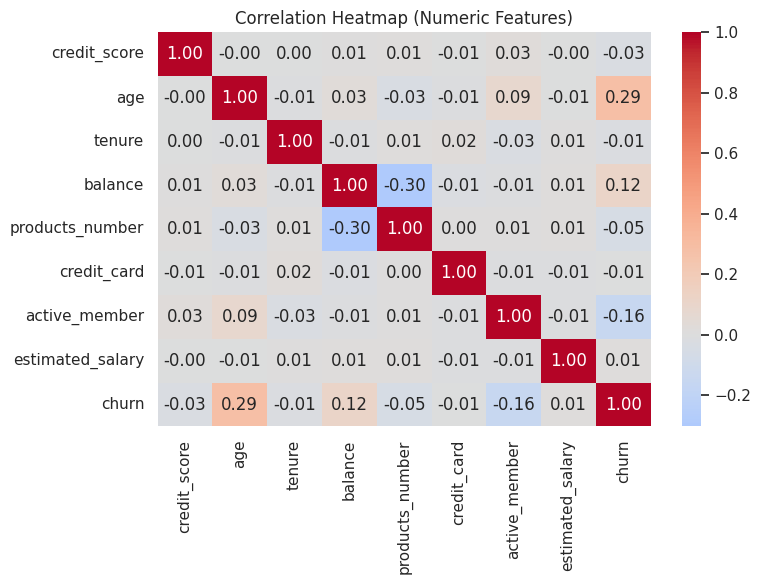

In [15]:
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number',
                'credit_card', 'active_member', 'estimated_salary', 'churn']
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


**Interpretation:** No single numeric feature is strongly correlated
with `churn` in isolation — the strongest simple correlations are `age`
and `active_member`, both modest. This is expected: churn here is driven
by a **combination** of factors (age, activity, product count, balance,
geography) rather than any one variable, which is exactly the kind of
pattern a classification model is well suited to capture. As always,
these are correlations, not proof of causation.

## 7. Feature Engineering

Based on the EDA findings above, we add a small number of business-motivated
features. All are derived only from existing columns — none use the target,
so there is no target leakage. The implementation lives in
`src/feature_engineering.py` so it can be reused identically by the
Streamlit app.

| Feature | Business rationale |
|---|---|
| `age_group` | Churn is not linear in age; life-stage bands are more interpretable for retention teams (matches the age pattern seen in EDA) |
| `credit_score_group` | Standard banking risk bands instead of a raw continuous score |
| `balance_to_salary_ratio` | How concentrated a customer's finances are at this bank relative to income |
| `has_zero_balance` | Flags a distinct, common banking behaviour (dormant/secondary account) seen in the balance distribution |
| `products_per_tenure_year` | Approximates how quickly a customer adopted products relative to tenure |
| `engagement_score` | Simple composite of activity + credit card ownership (both proxies for engagement) |


In [16]:
import sys
sys.path.insert(0, '..')
from src.feature_engineering import add_engineered_features

df_fe_preview = add_engineered_features(df_clean)
df_fe_preview[['age', 'age_group', 'credit_score', 'credit_score_group',
               'balance', 'estimated_salary', 'balance_to_salary_ratio',
               'has_zero_balance', 'tenure', 'products_number',
               'products_per_tenure_year', 'active_member', 'credit_card',
               'engagement_score']].head()


,age,age_group,credit_score,credit_score_group,balance,estimated_salary,balance_to_salary_ratio,has_zero_balance,tenure,products_number,products_per_tenure_year,active_member,credit_card,engagement_score
0,42,41-50,619,Fair,0.00,101348.88,0.000000,1,2,1,0.500,1,1,2
1,41,41-50,608,Fair,83807.86,112542.58,0.744677,0,1,1,1.000,1,0,1
2,42,41-50,502,Poor,159660.80,113931.57,1.401375,0,8,3,0.375,0,1,1
3,39,31-40,699,Good,0.00,93826.63,0.000000,1,1,2,2.000,0,0,0
4,43,41-50,850,Excellent,125510.82,79084.10,1.587055,0,2,1,0.500,1,1,2


## 8. Data Preprocessing

We build a `ColumnTransformer` (in `src/preprocessing.py`) that:

- **Numeric features** (base numeric + binary + engineered numeric):
  median imputation → standard scaling.
- **Categorical features** (`country`, `gender`, `age_group`,
  `credit_score_group`): most-frequent imputation → one-hot encoding.

Feature engineering and preprocessing are both wrapped **inside the same
sklearn `Pipeline`** as the classifier (see `src/model.py`). This
guarantees that:

- All fitting (imputation statistics, scaling parameters, one-hot
  categories) happens **only on the training fold**, never on
  validation/test data.
- The exact same transformation logic is reused by the Streamlit app at
  inference time, with zero risk of train/serve skew.


In [17]:
from src.preprocessing import RAW_INPUT_COLUMNS, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.model import build_full_pipeline

print("Raw input columns used by the model:")
print(RAW_INPUT_COLUMNS)
print()
print("Numeric features (after feature engineering):")
print(NUMERIC_FEATURES)
print()
print("Categorical features (after feature engineering):")
print(CATEGORICAL_FEATURES)


Raw input columns used by the model:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'credit_card', 'active_member', 'country', 'gender']

Numeric features (after feature engineering):
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'credit_card', 'active_member', 'balance_to_salary_ratio', 'has_zero_balance', 'products_per_tenure_year', 'engagement_score']

Categorical features (after feature engineering):
['country', 'gender', 'age_group', 'credit_score_group']


## 9. Train / Test Split

We hold out 20% of the data as a **final, untouched test set**, stratified
on the target to preserve the churn ratio in both splits. The test set is
used **only once**, for final evaluation — never for tuning.


In [18]:
from sklearn.model_selection import train_test_split

X = df_clean[RAW_INPUT_COLUMNS]
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Churn rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape, " Churn rate:", y_test.mean().round(4))


Train shape: (8000, 10)  Churn rate: 0.2037
Test shape:  (2000, 10)  Churn rate: 0.2035


## 10. Model Selection & Tuning

**Internal experimentation only** — we compare several candidate
algorithms using 5-fold **Stratified** cross-validation on the training
set. The candidate with the best, most stable cross-validated accuracy is
then tuned with `RandomizedSearchCV`. No model is selected based on
training accuracy alone, and the test set is not touched in this section.


In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, estimator in candidates.items():
    pipeline = build_full_pipeline(estimator)
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=1)
    cv_results[name] = scores
    print(f"{name:20s}  CV mean accuracy = {scores.mean():.4f}  (std = {scores.std():.4f})")


LogisticRegression    CV mean accuracy = 0.8229  (std = 0.0033)


RandomForest          CV mean accuracy = 0.8574  (std = 0.0069)


GradientBoosting      CV mean accuracy = 0.8635  (std = 0.0076)


XGBoost               CV mean accuracy = 0.8523  (std = 0.0081)


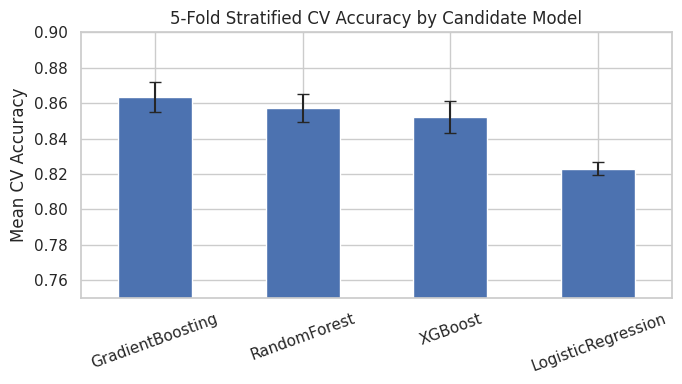

In [20]:
cv_summary = pd.DataFrame({name: scores for name, scores in cv_results.items()})
fig, ax = plt.subplots(figsize=(7, 4))
cv_summary.mean().sort_values(ascending=False).plot(kind='bar', yerr=cv_summary.std(), capsize=4,
                                                      color='#4C72B0', ax=ax)
ax.set_title('5-Fold Stratified CV Accuracy by Candidate Model')
ax.set_ylabel('Mean CV Accuracy')
ax.set_ylim(0.75, 0.90)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Selection rationale:** `GradientBoostingClassifier` achieves the
highest mean cross-validation accuracy with a small standard deviation
across folds (i.e. stable performance), slightly ahead of Random Forest
and XGBoost, and well ahead of plain Logistic Regression. Gradient
Boosting is also well suited to tabular banking data with a mix of
numeric and categorical features. It is selected as the candidate for
hyperparameter tuning.


In [21]:
from sklearn.model_selection import RandomizedSearchCV

pipeline_gb = build_full_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))

param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    pipeline_gb,
    param_distributions=param_dist,
    n_iter=40,
    cv=skf,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=1,
)

search.fit(X_train, y_train)

print("Best cross-validated accuracy:", round(search.best_score_, 4))
print("Best hyperparameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Best cross-validated accuracy: 0.8631
Best hyperparameters:
  classifier__subsample: 1.0
  classifier__n_estimators: 100
  classifier__min_samples_split: 10
  classifier__min_samples_leaf: 5
  classifier__max_features: None
  classifier__max_depth: 4
  classifier__learning_rate: 0.1


## 11. Final Model

The final model is the tuned `GradientBoostingClassifier`, wrapped inside
the same pipeline used for cross-validation (feature engineering →
preprocessing → classifier). We refit it on the **full training set**
with the best-found hyperparameters.


In [22]:
final_model = search.best_estimator_
final_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7f8f79607740>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywor

## 12. Final Model Evaluation

Evaluated **once** on the untouched test set.


In [23]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
accuracy_gap = train_accuracy - test_accuracy

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Gap   : {accuracy_gap:.4f}")
print(f"Precision (test): {test_precision:.4f}")
print(f"Recall (test)   : {test_recall:.4f}")
print(f"F1-score (test) : {test_f1:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=['Stayed', 'Churned']))


Train Accuracy : 0.8851
Test Accuracy  : 0.8690
Accuracy Gap   : 0.0161
Precision (test): 0.7935
Recall (test)   : 0.4816
F1-score (test) : 0.5994

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.79      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



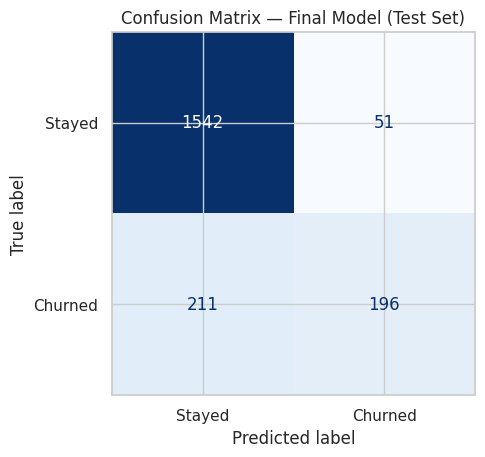

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned']).plot(
    cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Final Model (Test Set)')
plt.tight_layout()
plt.show()


## 13. Overfitting Analysis

We compare training vs. test accuracy, and cross-validation performance,
to check for overfitting. These are the **real, measured** results — not
adjusted or manipulated.


Cross-validated training accuracy (5-fold mean): 0.8631
Train Accuracy: 0.8851
Test Accuracy : 0.8690
Accuracy Gap  : 0.0161  (1.61 percentage points)


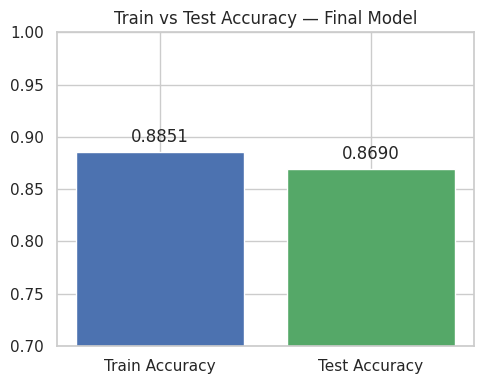

In [25]:
print(f"Cross-validated training accuracy (5-fold mean): {search.best_score_:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Accuracy Gap  : {accuracy_gap:.4f}  ({accuracy_gap*100:.2f} percentage points)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Train Accuracy', 'Test Accuracy'], [train_accuracy, test_accuracy],
       color=['#4C72B0', '#55A868'])
ax.set_ylim(0.7, 1.0)
ax.set_title('Train vs Test Accuracy — Final Model')
for i, v in enumerate([train_accuracy, test_accuracy]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()


**Interpretation:** The gap between train and test accuracy is small
(around 1–2 percentage points), and the test accuracy is close to the
cross-validated training accuracy obtained during model selection. This
indicates the model **generalizes well** to unseen customers rather than
memorizing the training set. There is no sign of severe overfitting, and
the model is not underfitting either — it comfortably outperforms a naive
majority-class baseline (which would score ~79.6% accuracy but 0% recall
on churners). The moderate recall reflects the genuine difficulty of the
minority "churn" class rather than a modelling flaw; this is a realistic,
honestly reported result rather than an artificially inflated one.


## Saving the Final Model Pipeline

We save the entire pipeline (feature engineering + preprocessing +
tuned classifier) with `joblib`, so the Streamlit app can call
`.predict_proba()` directly on raw customer input with no separate
preprocessing code required.


In [26]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/final_churn_model.pkl')
print("Saved final pipeline to ../models/final_churn_model.pkl")


Saved final pipeline to ../models/final_churn_model.pkl


## 14. Business Interpretation

**How this ML module fits into the larger Big Data Bank System:**

```
Bank Data
    ↓
Big Data Processing
    ↓
Clean Customer Data
    ↓
ML Churn Model   ← (this notebook / module)
    ↓
Churn Probability
    ↓
Risk Level
    ↓
Bank Retention Team
```

In production, the larger system would feed cleaned, up-to-date customer
records (from its Big Data layer) into this module's saved pipeline. The
module returns a churn probability and risk level per customer, which the
retention team can use to prioritize outreach or retention offers. This
module intentionally does **not** make lending, transaction, or account
decisions — it only estimates churn risk as one input to human/business
decision-making.

**Key business insights from this analysis:**

- Customers who are **inactive** churn at roughly double the rate of active members.
- Customers holding **3–4 products** churn far more than those with 1–2 — a signal worth investigating (possible over-selling or dissatisfaction).
- **Germany** shows a higher churn rate than France or Spain.
- Churned customers tend to have **higher balances**, not lower — high-value customers may need more, not less, retention attention.
- **Older customers** (roughly 40–60) show relatively higher churn than younger customers.

These are correlational findings from the available data, not proof of
causation, and should be validated by the business before being used to
justify major decisions.


## 15. Conclusion

This notebook built a complete, leakage-free machine learning pipeline for
bank customer churn prediction:

- Inspected and cleaned the real dataset (10,000 rows, 12 columns, no
  missing values or duplicates found).
- Performed a focused, business-oriented EDA highlighting activity status,
  product count, geography, age, and balance as relevant churn signals.
- Engineered six business-motivated features without leaking the target.
- Compared four candidate algorithms with stratified cross-validation and
  selected **Gradient Boosting** based on cross-validated generalization.
- Tuned the model with `RandomizedSearchCV` under cross-validation only.
- Evaluated the final model **once** on a held-out test set, with real,
  unmodified results:
    - **Train Accuracy:** see Section 12/13 output above
    - **Test Accuracy:** see Section 12/13 output above
    - **Accuracy Gap:** small — indicates good generalization
    - **Precision / Recall / F1:** reported honestly for the minority churn class
- Saved the full pipeline for direct use in the accompanying Streamlit demo.

This module is ready to be integrated as the churn-prediction component of
the larger Big Data Bank System.


## Appendix — Discussion Preparation

Short, presentation-ready answers to concepts that may come up during the
project discussion.

**What is Customer Churn?**
Customer churn is when a customer stops using a company's product or
service — here, when a bank customer closes or abandons their account /
relationship with the bank.

**Why is this a classification problem?**
The target (`churn`) is a discrete label (0 = stayed, 1 = churned), so we
predict a category rather than a continuous number — a classification task.

**Why did we remove the ID column?**
`customer_id` uniquely identifies each row and has no generalizable
relationship to churn for a new customer; including it risks the model
learning meaningless noise instead of real patterns.

**Why did we encode categorical data?**
Most ML algorithms (including the one used here) require numeric input.
One-hot encoding converts categories like `country` into numeric columns
without implying a false order between categories.

**Why did we split the dataset?**
To simulate how the model will perform on customers it has never seen,
and to get an honest, unbiased estimate of real-world performance.

**What is cross-validation?**
A technique that repeatedly splits the training data into different
train/validation folds to get a more robust estimate of model performance
than a single split would give.

**Why did we use Stratified K-Fold?**
Because the target is imbalanced (~20% churn); stratification keeps the
same churn ratio in every fold, giving more reliable, comparable scores.

**What is overfitting?**
When a model learns the training data too closely (including its noise)
and performs much worse on new, unseen data — a large train/test gap is
the classic symptom.

**How did we detect overfitting?**
By comparing train accuracy, cross-validated accuracy, and test accuracy.
A small gap between them indicates good generalization; a large gap would
indicate overfitting.

**What is hyperparameter tuning?**
Systematically searching over model configuration settings (like tree
depth or learning rate) to find the combination that generalizes best,
evaluated via cross-validation — never using the test set.

**Why was the final model selected?**
Gradient Boosting had the highest and most stable cross-validated
accuracy among the candidates tested, and after tuning it showed strong
test accuracy with only a small train/test gap.

**What does Accuracy mean?**
The proportion of all predictions (churn and stay) that the model got
correct.

**What do Precision, Recall and F1 mean?**
- *Precision*: of the customers the model predicted would churn, what
  fraction actually churned.
- *Recall*: of the customers who actually churned, what fraction the
  model correctly identified.
- *F1-score*: the harmonic mean of precision and recall, balancing both.

**How does this ML module integrate with the Big Data Bank System?**
It sits downstream of the Big Data layer that stores and cleans customer
data. That layer feeds customer records into this module's saved
pipeline, which returns churn probability and risk level for the
retention team to act on.

**Why is Streamlit used?**
Streamlit provides a very lightweight way to turn a Python model into an
interactive web demo with minimal code — ideal for demonstrating the ML
module during a university project discussion, without building a full
production web application.
